# Netflix Content Analysis and Recent Content Prediction

## Problem Definition
The aim of this project is to analyze Netflix content data and identify patterns related to content type, genre, release year, and duration. In addition to exploratory data analysis, a machine learning model will be developed to predict whether a title is recent or not.

A title is considered **recent** if it was released in or after 2016. This problem is formulated as a binary classification task.

## Business Perspective
Understanding recent content trends may help digital streaming platforms better understand catalog structure and support content planning decisions.

## Success Criterion
The project will be considered successful if the analysis reveals meaningful insights about the dataset and if the final classification model can reasonably distinguish recent titles from older ones.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv"
df = pd.read_csv(url)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [2]:
df.shape

(7787, 12)

In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [5]:
df.isnull().sum().sort_values(ascending=False)

director        2389
cast             718
country          507
date_added        10
rating             7
title              0
show_id            0
type               0
release_year       0
duration           0
listed_in          0
description        0
dtype: int64

In [6]:
df = df.drop(['show_id', 'description', 'cast', 'director'], axis=1)

In [7]:
df['country'] = df['country'].fillna('Unknown')

In [8]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [9]:
df = df.drop('date_added', axis=1)

## Data Cleaning and Preparation

During the data cleaning process, no rows were removed from the dataset.

However, several columns such as `show_id`, `description`, `cast`, `director`, and `date_added` were dropped. These columns were either not relevant for the modeling task or contained too many unique or complex values.

Missing values in the `country` column were filled with "Unknown", while missing values in the `rating` column were filled using the mode.

These steps ensured that the dataset remained complete while removing unnecessary complexity.

In [10]:
df.head()

,type,title,country,release_year,rating,duration,listed_in
0,TV Show,3%,Brazil,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,Movie,7:19,Mexico,2016,TV-MA,93 min,"Dramas, International Movies"
2,Movie,23:59,Singapore,2011,R,78 min,"Horror Movies, International Movies"
3,Movie,9,United States,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi..."
4,Movie,21,United States,2008,PG-13,123 min,Dramas


In [11]:
df.isnull().sum().sort_values(ascending=False)

type            0
title           0
country         0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [12]:
df['is_recent'] = (df['release_year'] >= 2016).astype(int)

In [13]:
df['is_recent'].value_counts()

is_recent
1    4910
0    2877
Name: count, dtype: int64

## Target Variable Creation

A new binary target variable called `is_recent` was created.

Titles released in or after 2016 are labeled as 1 (recent), while older titles are labeled as 0 (not recent).

This transformation converts the problem into a binary classification task.

The year 2016 was chosen as a threshold to distinguish between recent and older content, as Netflix significantly increased its content production after this period.

<Axes: xlabel='is_recent'>

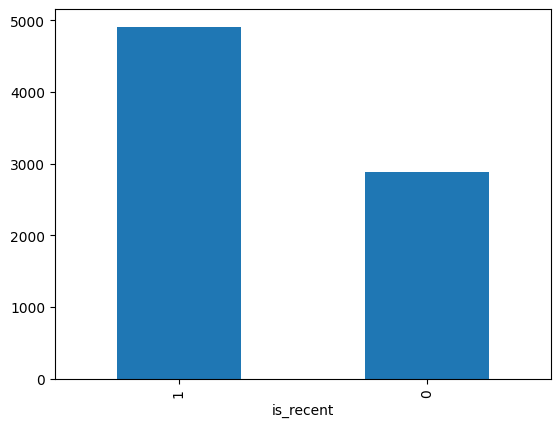

In [14]:
df['is_recent'].value_counts().plot(kind='bar')

### Distribution of Target Variable

The distribution of the target variable shows the number of recent and non-recent titles in the dataset.

There appears to be a higher number of recent titles, indicating that Netflix has significantly expanded its content in recent years. This suggests that the dataset may be slightly imbalanced.

<Axes: xlabel='type'>

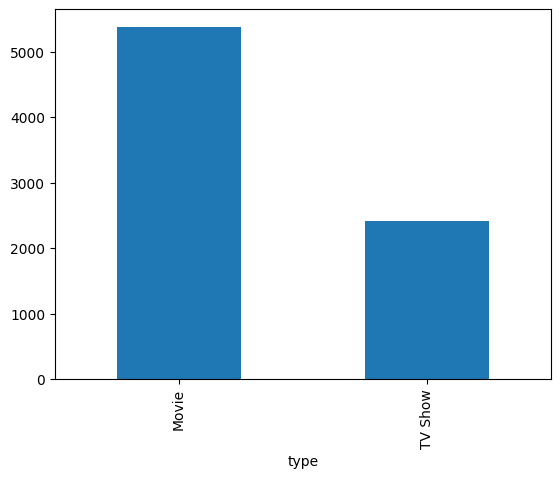

In [15]:
df['type'].value_counts().plot(kind='bar')

### Distribution of Content Type

The chart shows that movies are more common than TV shows on Netflix.

This indicates that Netflix's content catalog is dominated by movies, which may influence user preferences and platform strategy.

In [16]:
df['release_year'].value_counts()

release_year
2018    1121
2017    1012
2019     996
2016     882
2020     868
        ... 
1966       1
1925       1
1964       1
1947       1
1959       1
Name: count, Length: 73, dtype: int64

<Axes: xlabel='release_year'>

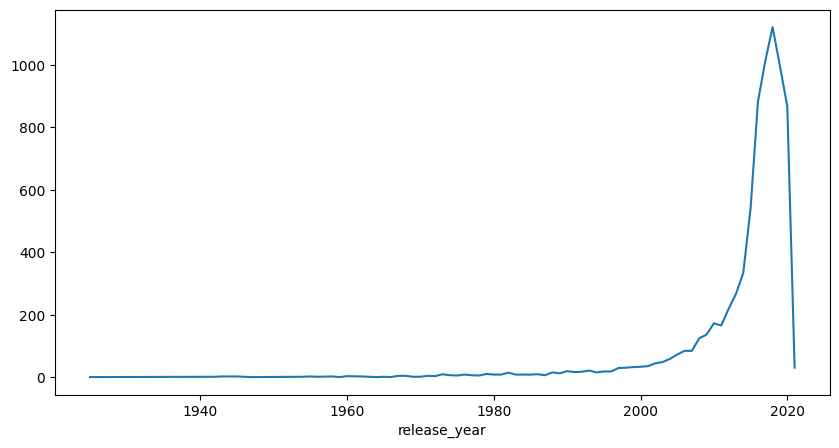

In [17]:
df['release_year'].value_counts().sort_index().plot(figsize=(10,5))

### Content Production Over Time

The number of titles has increased significantly after 2010.

This suggests that Netflix has rapidly expanded its content library in recent years, especially after becoming a global streaming platform.

<Axes: xlabel='listed_in'>

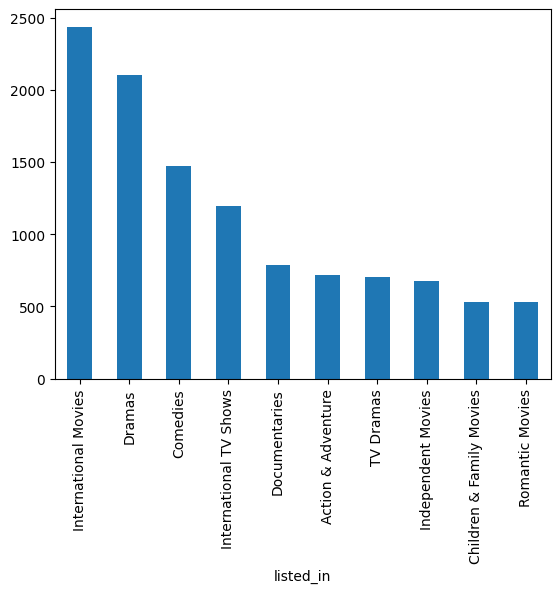

In [18]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')

### Most Common Genres

Drama and Comedy are the most common genres on Netflix.

This suggests that these genres are highly preferred and frequently produced, possibly due to higher audience demand.

## Impact on Modeling

The insights obtained from the exploratory data analysis guided the next steps of the project.

For example, the increase in content over time influenced the creation of the `content_age` feature.

The distribution of genres and content types also highlighted the importance of categorical variables, which will be encoded during preprocessing.

These findings helped shape the feature engineering and modeling strategy.

In [19]:
df['duration'].dropna().head()

0    4 Seasons
1       93 min
2       78 min
3       80 min
4      123 min
Name: duration, dtype: object

In [20]:
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)

<Axes: >

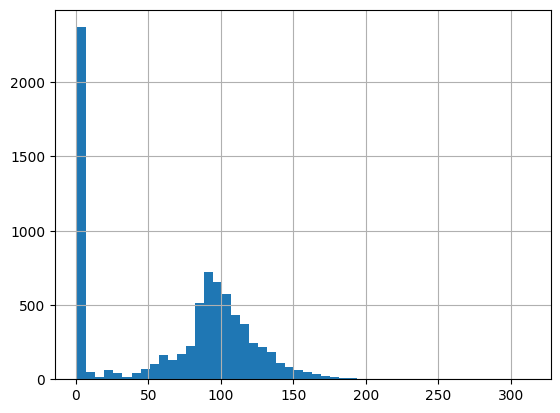

In [21]:
df['duration_int'].hist(bins=50)

In [22]:
num_cols = ['release_year', 'duration_int']

In [23]:
df[num_cols].skew()

release_year   -3.619166
duration_int   -0.164489
dtype: float64

## Skewness Analysis

The skewness values of numerical features were calculated to better understand their distributions.

The `release_year` feature shows a strong negative skew (-3.61), indicating that most of the values are concentrated in recent years, with fewer older titles.

On the other hand, the `duration_int` feature has a skewness close to zero (-0.16), suggesting that it is approximately normally distributed.

Since `duration_int` does not show significant skewness, no transformation is required for this feature.

The skewness in `release_year` reflects the rapid growth of Netflix content in recent years, which aligns with the findings from the exploratory data analysis.

## Transformation Decision

Although log transformation is commonly used to reduce skewness in numerical features, it was not applied in this project.

The `duration_int` feature has a skewness close to zero, indicating an approximately normal distribution. Therefore, applying a transformation was not necessary.

The `release_year` feature shows skewness due to the natural growth of content over time, which reflects real-world patterns rather than data distortion.

For this reason, no transformation was applied.

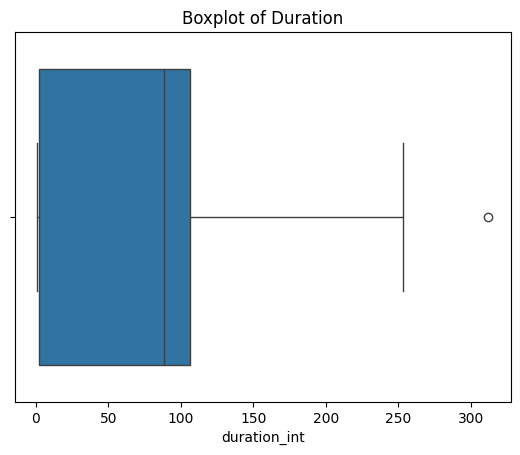

In [24]:
sns.boxplot(x=df['duration_int'])
plt.title('Boxplot of Duration')
plt.show()

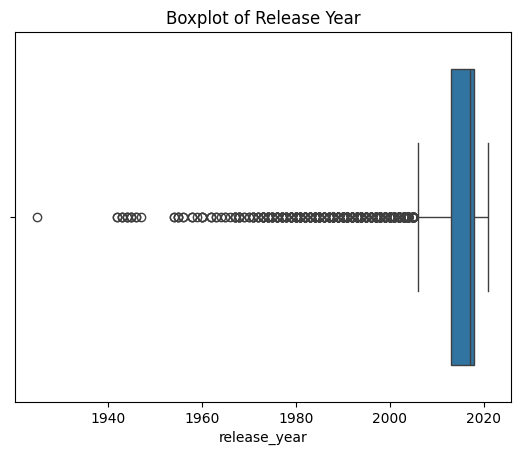

In [25]:
sns.boxplot(x=df['release_year'])
plt.title('Boxplot of Release Year')
plt.show()

## Outlier Analysis

Boxplots were used to detect potential outliers in the numerical features.

The `duration_int` feature shows some extreme values, but these values represent real-world cases (such as very long movies or series) and were not removed.

Similarly, the `release_year` feature contains older titles, which are valid observations.

Therefore, no outlier removal was applied in this project.

Outliers were retained because they represent valid real-world data and removing them could lead to information loss.

In [26]:
df['content_age'] = 2024 - df['release_year']

In [27]:
df['title_length'] = df['title'].apply(len)

In [28]:
df['genre_count'] = df['listed_in'].apply(lambda x: len(x.split(',')))

In [29]:
df.head()

,type,title,country,release_year,rating,duration,listed_in,is_recent,duration_int,content_age,title_length,genre_count
0,TV Show,3%,Brazil,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",1,4.0,4,2,3
1,Movie,7:19,Mexico,2016,TV-MA,93 min,"Dramas, International Movies",1,93.0,8,4,2
2,Movie,23:59,Singapore,2011,R,78 min,"Horror Movies, International Movies",0,78.0,13,5,2
3,Movie,9,United States,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...",0,80.0,15,1,3
4,Movie,21,United States,2008,PG-13,123 min,Dramas,0,123.0,16,2,1


## Feature Engineering

New features were created to enhance the model's ability to capture patterns in the data.

- `content_age`: Represents how old a title is, based on its release year.
- `title_length`: Measures the length of the title, which may reflect naming patterns.
- `genre_count`: Indicates the number of genres associated with each title.

These features were designed based on insights obtained from the exploratory data analysis.

In [30]:
df = df.drop('title', axis=1)

### Feature Selection

After extracting meaningful information from the `title` column through the `title_length` feature, the original `title` column was removed.

This is because the `title` column contains high-cardinality text data that is not directly suitable for modeling and could negatively impact performance if included without advanced text processing techniques.

Therefore, it was excluded to simplify the model and focus on more structured features.

In [31]:
df = df.drop('content_age', axis=1)

In [32]:
X = df.drop('is_recent', axis=1)
y = df['is_recent']

## Data Leakage Consideration

The feature `content_age` was removed from the model.

This is because it is directly derived from `release_year`, which is used to define the target variable (`is_recent`).

Including this feature would lead to data leakage, allowing the model to achieve artificially high performance.

After removing this feature, the model evaluation results became more realistic.

In [33]:
df = df.drop('release_year', axis=1)

In [34]:
X = df.drop('is_recent', axis=1)
y = df['is_recent']

In [35]:
X = df.drop('is_recent', axis=1)
y = df['is_recent']

In [36]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['type', 'country', 'rating', 'duration', 'listed_in']
Numerical: ['duration_int', 'title_length', 'genre_count']


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

## Preprocessing and Pipeline

A preprocessing pipeline was created to handle both numerical and categorical features.

Numerical features were scaled using StandardScaler to ensure that all features have a similar scale.

Categorical features were encoded using OneHotEncoder to convert them into a numerical format suitable for machine learning models.

This preprocessing step was integrated into a pipeline to ensure a consistent and reproducible workflow.

In [39]:
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [40]:
log_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [41]:
y_pred_log = log_pipeline.predict(X_test)

In [42]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression F1:", f1_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7008985879332478
Logistic Regression F1: 0.7753134040501446
              precision    recall  f1-score   support

           0       0.62      0.50      0.55       576
           1       0.74      0.82      0.78       982

    accuracy                           0.70      1558
   macro avg       0.68      0.66      0.66      1558
weighted avg       0.69      0.70      0.69      1558



In [43]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [44]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [45]:
y_pred_rf = rf_pipeline.predict(X_test)

In [46]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7028241335044929
Random Forest F1: 0.7742564602632862
              precision    recall  f1-score   support

           0       0.62      0.52      0.57       576
           1       0.74      0.81      0.77       982

    accuracy                           0.70      1558
   macro avg       0.68      0.67      0.67      1558
weighted avg       0.70      0.70      0.70      1558



In [47]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

In [48]:
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [49]:
y_pred_gb = gb_pipeline.predict(X_test)

In [50]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting F1:", f1_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7041078305519898
Gradient Boosting F1: 0.782033096926714
              precision    recall  f1-score   support

           0       0.64      0.47      0.54       576
           1       0.73      0.84      0.78       982

    accuracy                           0.70      1558
   macro avg       0.68      0.66      0.66      1558
weighted avg       0.69      0.70      0.69      1558



In [51]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.700899,0.775313
1,Random Forest,0.702824,0.774256
2,Gradient Boosting,0.704108,0.782033


## Model Comparison

Three models were evaluated in this project: Logistic Regression, Random Forest, and Gradient Boosting.

All models achieved similar performance, with accuracy around 70% and F1 scores between 0.77 and 0.78.

Among the models, Gradient Boosting achieved the highest F1 score, indicating slightly better performance in balancing precision and recall.

However, the performance difference between the models is relatively small. This suggests that the dataset does not contain highly complex patterns that require advanced models.

Logistic Regression performed competitively despite its simplicity, making it a strong baseline model. Random Forest and Gradient Boosting provided only marginal improvements.

Therefore, while Gradient Boosting achieved the best numerical performance, Logistic Regression remains a good alternative due to its simplicity and interpretability.

The small performance differences between models indicate that feature quality may be more important than model complexity for this task.

This result suggests that improving feature engineering or incorporating additional data sources could lead to better performance gains than switching to more complex models.

## Hyperparameter Tuning

In this project, hyperparameter tuning was not applied.

The main objective was to compare different models and understand their baseline performance rather than maximizing predictive accuracy.

All models were trained using their default parameters to ensure a fair and consistent comparison.

Additionally, the performance differences between the models were relatively small, indicating that further optimization might not lead to significant improvements.

Therefore, hyperparameter tuning was not considered necessary within the scope of this project.

Moreover, hyperparameter tuning techniques such as GridSearchCV or RandomizedSearchCV can be computationally expensive and were beyond the scope of this analysis.

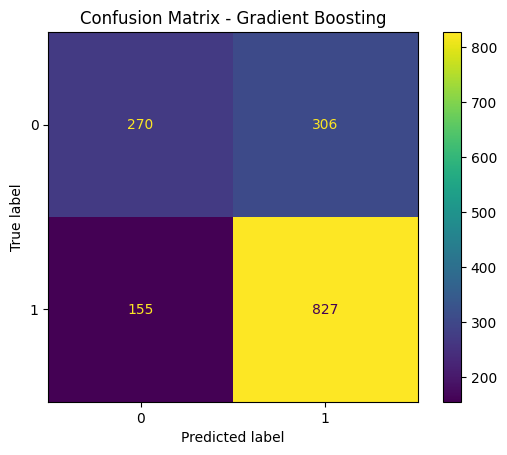

In [52]:
cm = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

## Confusion Matrix Analysis

The confusion matrix provides a detailed view of the model's predictions.

- The model correctly predicted 827 recent titles (True Positives).
- It correctly identified 270 non-recent titles (True Negatives).
- However, 306 non-recent titles were incorrectly classified as recent (False Positives).
- Additionally, 155 recent titles were incorrectly classified as non-recent (False Negatives).

The model performs better at identifying recent content compared to non-recent content. This can be observed from the higher number of true positives.

However, the relatively high number of false positives indicates that the model tends to classify some older titles as recent.

Overall, the model shows reasonable performance but still makes noticeable classification errors.

This imbalance in predictions suggests that the model is slightly biased towards predicting the majority class (recent titles).

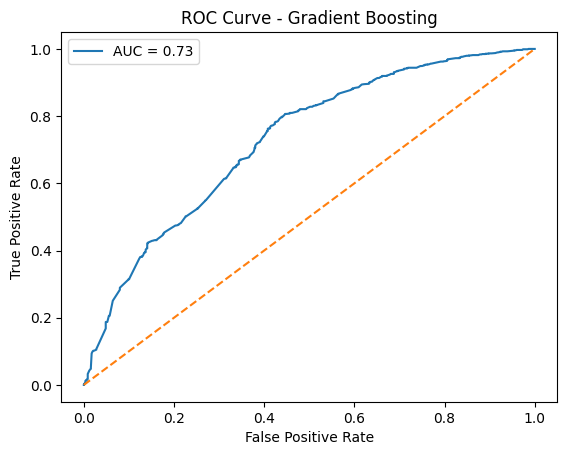

In [53]:
y_prob = gb_pipeline.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

## ROC Curve Analysis

The ROC curve illustrates the trade-off between the true positive rate and the false positive rate.

The AUC score of 0.73 indicates that the model has a moderate ability to distinguish between recent and non-recent titles.

This means that the model performs significantly better than random guessing (AUC = 0.50), but there is still room for improvement.

The curve shows that the model is capable of capturing useful patterns, although it is not highly accurate in separating the two classes.

This result is consistent with the overall model performance, where accuracy is around 70%, confirming that the model captures general trends but struggles with more subtle distinctions.

The ROC analysis supports the findings from the confusion matrix and evaluation metrics, showing that the model has moderate predictive power.

In [54]:
cv_scores = cross_val_score(gb_pipeline, X, y, cv=5, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.79033008 0.79192109 0.7915493  0.79435294 0.79924242]
Mean F1 score: 0.7934791659880063


## Cross-Validation Analysis

Cross-validation was performed to evaluate the model's performance across multiple data splits.

The F1 scores obtained from the 5-fold cross-validation are as follows:

[0.79, 0.79, 0.79, 0.79, 0.80]

The mean F1 score is approximately 0.79, which is consistent across all folds.

The consistency of the F1 scores across different folds indicates that the model is stable and does not suffer from significant overfitting.

The small variation between the scores suggests that the model generalizes well to unseen data.

This result confirms that the model performance observed in the test set is reliable and not due to a favorable data split.

The cross-validation results reinforce the robustness of the model and support its validity for this classification task.

This consistency also suggests that further improvements may require better feature engineering rather than model complexity.

## Evaluation Metrics Selection

In this project, classification metrics such as Accuracy, F1 Score, Precision, Recall, and ROC-AUC were used to evaluate model performance.

Regression metrics such as RMSE and R² were not used because the problem is formulated as a classification task, where the target variable is binary.

Therefore, classification metrics are more appropriate for evaluating model performance in this context.

## Conclusion

In this project, Netflix content data was analyzed to understand patterns related to content type, genre, and release trends. Based on this analysis, a machine learning model was developed to predict whether a title is recent or not.

The exploratory data analysis revealed that Netflix has significantly increased its content production in recent years and that certain genres such as Drama and Comedy dominate the platform.

Several machine learning models were evaluated, including Logistic Regression, Random Forest, and Gradient Boosting. Among these, Gradient Boosting achieved the highest performance, although the differences between models were relatively small.

The model achieved moderate performance, indicating that while some patterns can be captured, predicting content recency based only on the available features is not highly precise.

An important part of this project was identifying and correcting data leakage, which significantly improved the reliability of the results.

Overall, this project demonstrates the importance of proper data preprocessing, feature engineering, model evaluation, and critical thinking in machine learning workflows.

## Key Learnings and Benefits

This project provided valuable experience in building an end-to-end machine learning pipeline.

It helped develop a deeper understanding of data preprocessing techniques, including handling missing values, detecting skewness, and analyzing outliers.

The project also strengthened skills in feature engineering and demonstrated how new features can improve model performance.

Additionally, it highlighted the importance of selecting appropriate evaluation metrics and understanding the difference between classification and regression problems.

One of the most critical learnings was identifying and preventing data leakage, which is essential for building reliable and realistic models.

Finally, this project improved the ability to interpret model results and translate technical findings into meaningful insights.

## Practical Value of the Project

Unlike regression models that directly predict numerical values, this project provides insights for decision-making.

The model can be used to identify whether a title belongs to recent content trends. This can help understand how content characteristics relate to recency.

More importantly, the analysis highlights patterns such as the dominance of certain genres and the rapid growth of content in recent years.

These insights can support content planning decisions, such as identifying which types of content are more aligned with current trends.